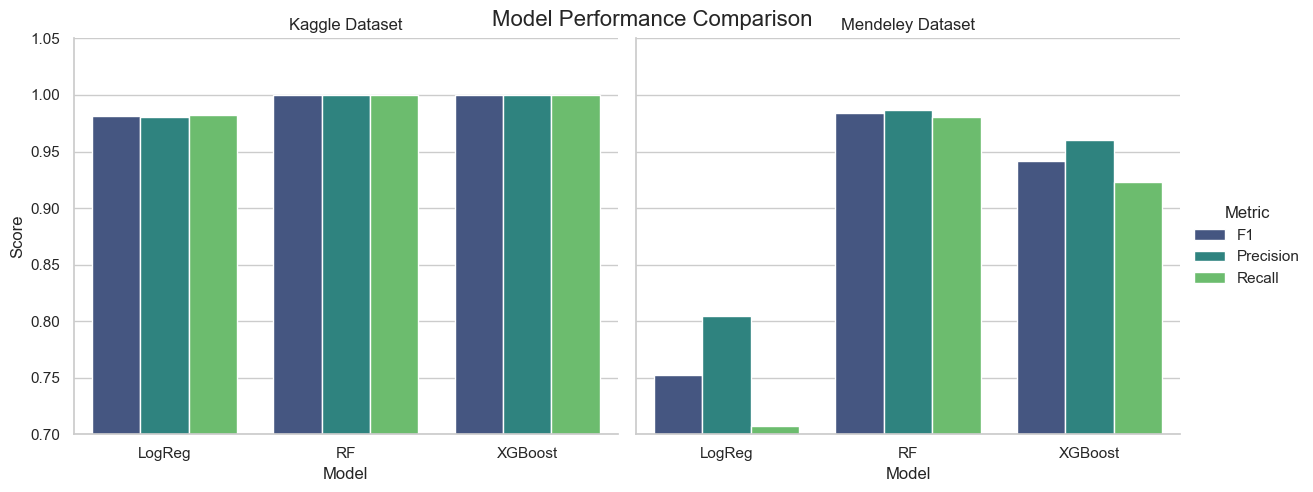

C:\Users\rimsh\AppData\Local\Temp\ipykernel_3120\2395103602.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g2 = sns.catplot(


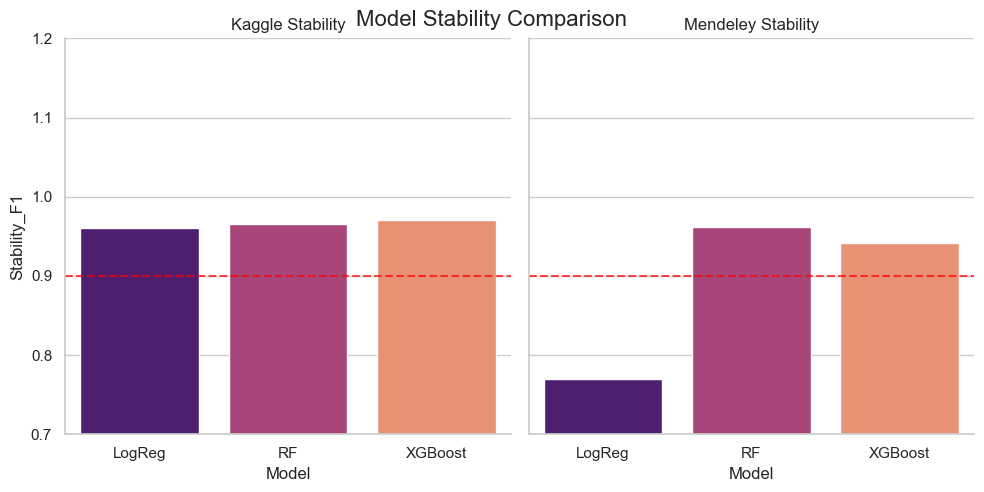

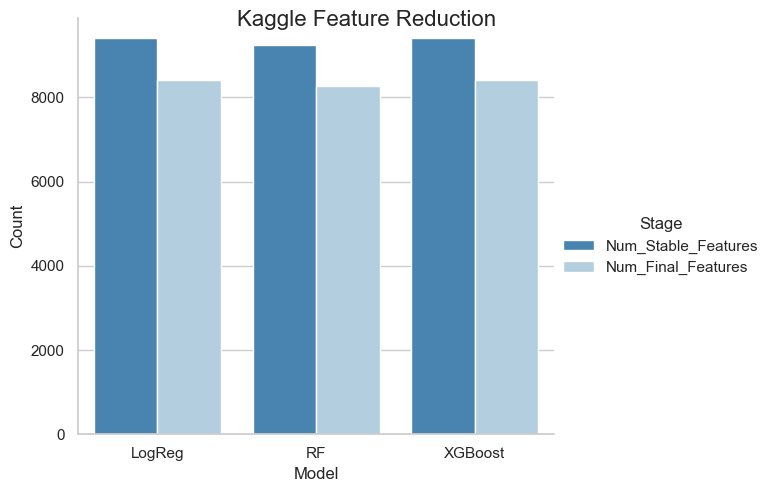

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
# 1. Load data
path = r"..\results\phase_3\final_reports\final_results_*.csv"
files = glob.glob(path) 
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

sns.set_theme(style="whitegrid")

# --- PLOT 1: Performance (Separated by Dataset) ---
df_perf = df.melt(id_vars=['Dataset', 'Model'], 
                   value_vars=['F1', 'Precision', 'Recall'], 
                   var_name='Metric', value_name='Score')

g1 = sns.catplot(
    data=df_perf, kind="bar",
    x="Model", y="Score", hue="Metric",
    col="Dataset", palette="viridis", 
    height=5, aspect=1.2,
    errorbar=None 
)

g1.set_titles("{col_name} Dataset")
g1.fig.suptitle("Model Performance Comparison", fontsize=16)
# Lowering the bottom limit to 0.8 (or 0.0) so lower scores are visible
g1.set(ylim=(0.7, 1.05)) 

plt.savefig('performance_summary.png', dpi=300)
plt.show()

# --- PLOT 2: Stability (Separated by Dataset) ---
g2 = sns.catplot(
    data=df, kind="bar",
    x="Model", y="Stability_F1",
    col="Dataset", palette="magma", height=5, aspect=1, errorbar=None 
)
g2.set_titles("{col_name} Stability")
# Adding the threshold line to each subplot
for ax in g2.axes.flat:
    ax.axhline(0.9, color='red', linestyle='--', alpha=0.7)
    ax.set_ylim(0.7, 1.2)
plt.savefig('stability_by_dataset.png', dpi=300)
g2.fig.suptitle("Model Stability Comparison", fontsize=16)
plt.show()
# --- PLOT 3: Feature Counts (Separated by Dataset) ---
df_feat = df.melt(id_vars=[ 'Model'], 
                  value_vars=['Num_Stable_Features', 'Num_Final_Features'], 
                  var_name='Stage', value_name='Count')

g3 = sns.catplot(
    data=df_feat, kind="bar",
    x="Model", y="Count", hue="Stage", palette="Blues_r", height=5, aspect=1.2, errorbar=None 
)

g3.fig.suptitle("Kaggle Feature Reduction", fontsize=16)
plt.savefig('feature_reduction_by_dataset.png', dpi=300)

plt.show()